# **MAG**netic **PAR**ticle **SOL**ver: `magparsol`

`magparsol` is a compact Python library that integrates the orbits of charged particles in prescribed electromagnetic fields. It covers relativistic and non-relativistic motion, and comes with tools to analyse and visualise the results. This notebook doubles as the package documentation. Each section introduces one piece of physics, runs it with the package, and **checks the result against the analytic expectation**. A failed check stops the notebook.

The equation of motion is the Lorentz force law,
$$
\frac{d(\gamma m\mathbf v)}{dt} = q\left(\mathbf E + \mathbf v\times\mathbf B\right),\qquad \frac{d\mathbf r}{dt} = \mathbf v .
$$
All quantities are in SI units. Fields are passed as `FieldModel` objects that return `(B, E)` for arrays of positions of shape `(N, 3)`, so ensembles of $N$ particles advance in one vectorised step.

### Package structure

```
MASS/Plasma/
├── magparsol/
│   ├── __init__.py          public API (from magparsol import *)
│   ├── constants.py         CODATA 2018 constants, IGRF-14 dipole
│   ├── fields.py            UniformB, UniformEB, CyclotronWaveField, EarthDipole, CustomField
│   ├── particles.py         ParticleState + initial-condition factories
│   ├── integrators/
│   │   ├── base.py          Integrator.run(), history recording, live plotting
│   │   ├── boris.py         BorisA, BorisB, BorisC
│   │   └── rungekutta.py    RKnonrel, RKrel (Dormand–Prince RK45, fixed or adaptive)
│   ├── diagnostics.py       TrajectoryHistory, gyro-quantities, dt checks
│   ├── plotting.py          trajectories, energy, speed, LivePlotter
│   ├── fieldlines.py        plot_field_lines
│   ├── radiation.py         Liénard power, FFT and retarded-time spectra
│   └── animation.py         plot_overview, GIF animation
└── magparsol.ipynb          this notebook
```

### Contents
1. Setup
2. Field models
3. Gyration in a uniform field
4. Magnetic mirror (`CustomField`)
5. $\mathbf E\times\mathbf B$ drift
6. Integrators: Boris vs Runge–Kutta
7. Cyclotron resonance
8. Trapped particles in the Earth's dipole
9. Radiation
10. Ensembles and thermal spectra
11. Overview figure and animations
12. Live plotting
13. Summary

## 1. Setup

`check` prints a measured value next to its theoretical value and asserts that they agree within a relative tolerance.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

import magparsol
from magparsol import *

plt.rcParams.update({
    "figure.dpi": 100, "font.size": 10, "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False, "legend.fontsize": 9,
})
print(f"magparsol {magparsol.__version__} | numpy {np.__version__} | matplotlib {mpl.__version__}")


def check(name, measured, expected, rtol):
    """Compare a measured value with theory and assert agreement within rtol."""
    err = abs(measured - expected) / abs(expected)
    print(f"  {name:<36s} {measured: .5g}  (theory {expected: .5g},  rel. err {err:.1e})")
    assert err < rtol, f"{name}: relative error {err:.2e} exceeds {rtol:g}"

magparsol 0.3.0 | numpy 2.4.6 | matplotlib 3.11.2


## 2. Field models

| class | field | notes |
|---|---|---|
| `UniformB(B)` | constant $\mathbf B$, $\mathbf E = 0$ | |
| `UniformEB(B, E)` | constant $\mathbf B$ and $\mathbf E$ | |
| `CyclotronWaveField(B, q, m, E_amp)` | constant $\mathbf B$ plus $E_y = E_0\sin\omega_c t$ | the wave frequency is set to $\omega_c = \lvert q\rvert B/m$ |
| `EarthDipole(tilt_deg, moment)` | tilted magnetic dipole | default: IGRF-14 (2025.0) tilt and moment |
| `CustomField(func, vector_api)` | any user function | `func(x, y, z, t) → (Bx, By, Bz, Ex, Ey, Ez)`, or `func(r, t) → (B, E)` with `vector_api=True` |

`plot_field_lines` chooses the representation from the field type:
- **Uniform fields** are drawn as arrow grids. A component perpendicular to the page is shown as ⊙ (out of the page) or ⊗ (into the page).
- **Dipole lines** are traced from the magnetic equator at fixed $L$ down to the Earth's surface. In a meridian plane they are the closed curves $r = L\cos^2\lambda$.
- **Other fields** are drawn as streamlines.

The example custom field is a paraxial **magnetic bottle**,
$$
\mathbf B = B_0\left(-\frac{xz}{L^2},\; -\frac{yz}{L^2},\; 1 + \frac{z^2}{L^2}\right),\qquad \nabla\cdot\mathbf B = 0 .
$$
It is written once in the scalar convention and once in the vector convention, and the two versions are checked to agree.

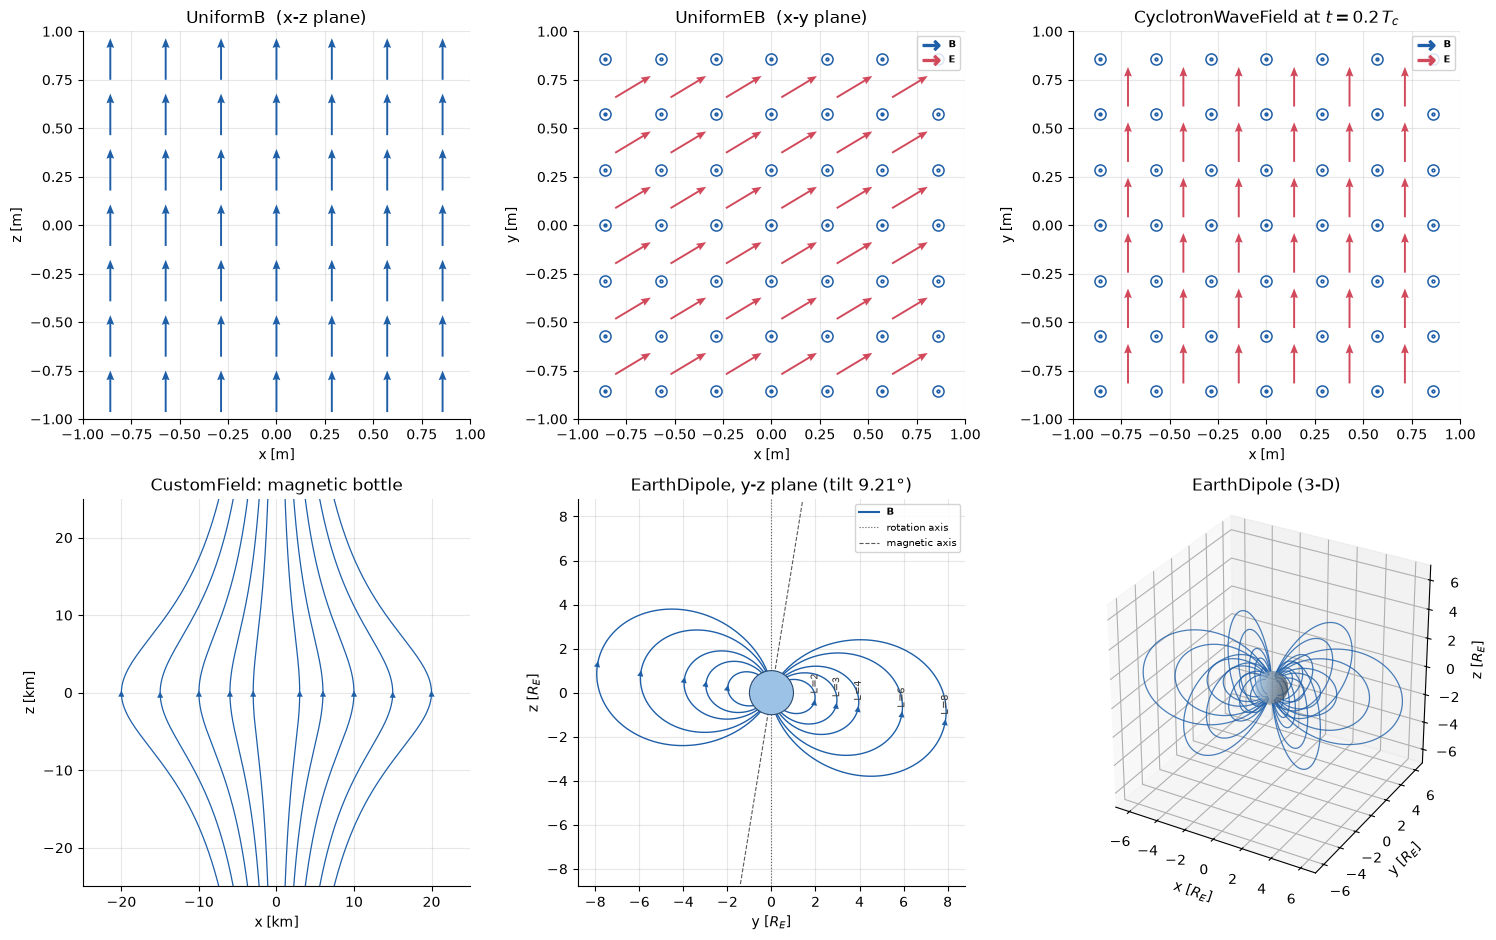

Equatorial surface field: 29.64 µT
  B_pole / B_equator                    2  (theory  2,  rel. err 2.2e-16)
  B(2 R_E) / B(R_E)                     0.125  (theory  0.125,  rel. err 0.0e+00)


In [2]:
def bottle(x, y, z, t, B0=1e-5, L=1e4):
    """Paraxial magnetic bottle (scalar / legacy API)."""
    k, zero = 1.0 / L**2, np.zeros_like(x)
    return -B0*k*x*z, -B0*k*y*z, B0*(1 + k*z**2), zero, zero, zero

def bottle_vec(r, t):
    """Same field through the vector API: r (N,3) → B, E (N,3)."""
    c = bottle(r[:, 0], r[:, 1], r[:, 2], t)
    return np.column_stack(c[:3]), np.column_stack(c[3:])

bottle_field = CustomField(bottle)
bottle_seeds = [[x*1e3, 0, 0] for x in (-20, -15, -10, -6, -3, 3, 6, 10, 15, 20)]   # midplane seeds
r_test = np.random.default_rng(0).normal(scale=1e4, size=(10, 3))
assert np.allclose(bottle_field(r_test, 0)[0], CustomField(bottle_vec, vector_api=True)(r_test, 0)[0])

dip = EarthDipole()
cw  = CyclotronWaveField(B=(0, 0, 1e-5), E_amp=1e-3)

fig = plt.figure(figsize=(15, 9.5))
ax = [fig.add_subplot(2, 3, i + 1) for i in range(5)] + [fig.add_subplot(2, 3, 6, projection="3d")]
plot_field_lines(UniformB(B=(0, 0, 1e-5)), projection="xz", ax=ax[0], title="UniformB  (x-z plane)")
plot_field_lines(UniformEB(B=(0, 0, 1e-5), E=(0.5, 0.3, 0)), components=("B", "E"),
                 projection="xy", ax=ax[1], title="UniformEB  (x-y plane)")
plot_field_lines(cw, components=("B", "E"), t=0.2 * 2*np.pi / cw.omega_c, projection="xy",
                 ax=ax[2], title=r"CyclotronWaveField at $t = 0.2\,T_c$")
plot_field_lines(bottle_field, projection="xz", length_unit=1e3, unit_label="km", ax_lim=25,
                 seed_points=bottle_seeds, ax=ax[3], title="CustomField: magnetic bottle")
plot_field_lines(dip, projection="yz", length_unit=R_EARTH, unit_label=r"$R_E$", ax=ax[4],
                 title=f"EarthDipole, y-z plane (tilt {dip.tilt_deg:.2f}°)")
plot_field_lines(dip, projection="3d", length_unit=R_EARTH, unit_label=r"$R_E$", ax_lim=7,
                 ax=ax[5], title="EarthDipole (3-D)")
fig.tight_layout(); plt.show()

# Dipole sanity checks: |B| at the pole is twice |B| at the equator, and B ∝ r^-3
B_eq   = np.linalg.norm(dip(np.array([R_EARTH, 0, 0]), 0)[0])
B_pole = np.linalg.norm(dip(R_EARTH * dip.axis, 0)[0])
print(f"Equatorial surface field: {B_eq*1e6:.2f} µT")
check("B_pole / B_equator", B_pole / B_eq, 2.0, 1e-12)
check("B(2 R_E) / B(R_E)", dip.B_equator(2*R_EARTH) / B_eq, 1/8, 1e-12)

## 3. Gyration in a uniform magnetic field

In a uniform $\mathbf B$ a particle gyrates around a field line and moves freely along it, so its orbit is a helix with
$$
\omega_c = \frac{\lvert q\rvert B}{\gamma m},\qquad T_c = \frac{2\pi}{\omega_c},\qquad r_L = \frac{\gamma m v_\perp}{\lvert q\rvert B}.
$$
The sense of rotation depends on the sign of the charge. Seen from the tip of $\mathbf B$, ions gyrate **clockwise** and electrons **anticlockwise**. The resulting current loop reduces the field inside it, so a plasma is diamagnetic.

`suggest_dt` returns a time step that resolves a gyroperiod with a given number of steps. `check_dt_resolution` warns if a step is too coarse.

proton: T_c = 6.559e-03 s,  r_L = 1.044e+02 m,  dt/T_c = 0.005
  proton gyroradius [m]                 104.39  (theory  104.4,  rel. err 8.2e-05)
  proton |ω| [rad/s]                    957.88  (theory  957.88,  rel. err 5.8e-08)
electron: T_c = 3.572e-06 s,  r_L = 5.686e-02 m,  dt/T_c = 0.005
  electron gyroradius [m]               0.056852  (theory  0.056856,  rel. err 8.2e-05)
  electron |ω| [rad/s]                  1.7588e+06  (theory  1.7588e+06,  rel. err 5.8e-08)


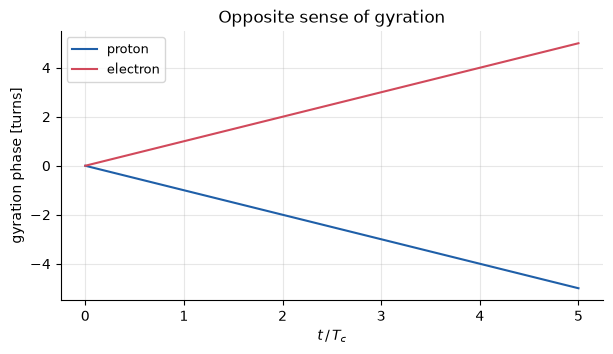

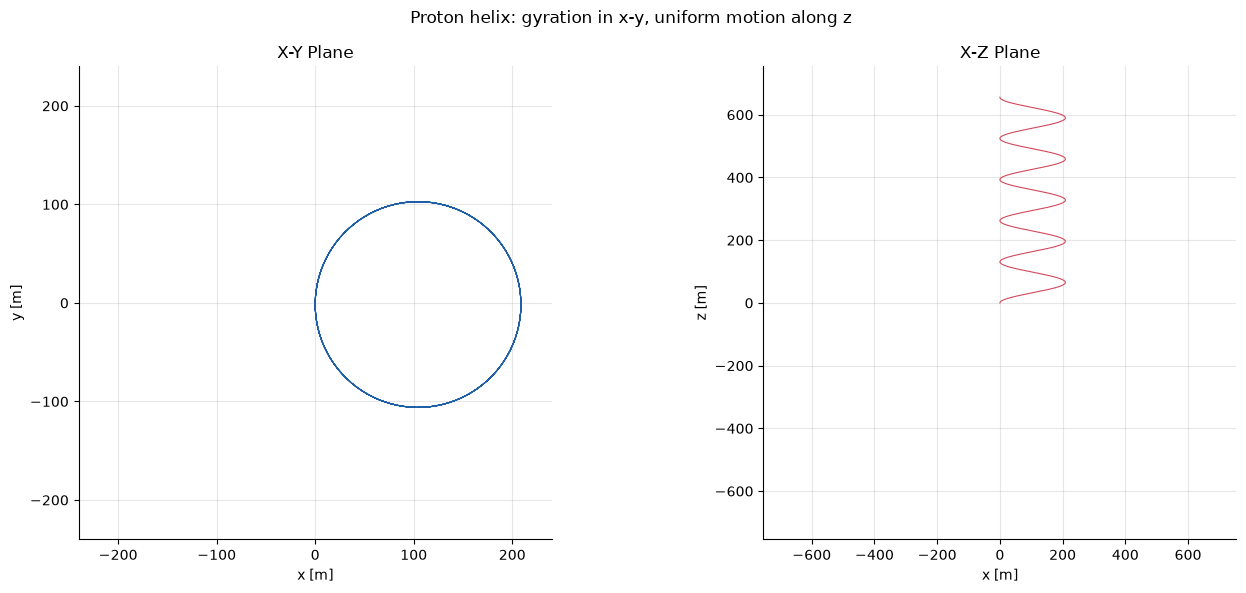

In [3]:
B0 = 1e-5                                   # 10 µT along z
fB = UniformB(B=(0, 0, B0))
v_perp, v_par = 1e5, 2e4                    # m/s

fig, ax = plt.subplots(figsize=(7, 3.5))
for q, m, name, col in [(Q_E, M_P, "proton", "#1f5fa8"), (-Q_E, M_E, "electron", "#d1495b")]:
    Tc, rL = gyroperiod(q, m, B0), gyroradius(m, v_perp, q, B0)
    dt = suggest_dt(q, m, B0, steps_per_gyration=200)
    print(f"{name}: T_c = {Tc:.3e} s,  r_L = {rL:.3e} m,  dt/T_c = {check_dt_resolution(dt, q, m, B0):.3f}")

    sim = BorisC(single_particle(q=q, m=m, v0=[0, v_perp, v_par]), fB,
                 dt=dt, t_max=5*Tc, relativistic=False)
    h = sim.run()
    x = h.r[:, 0, 0]
    phase = np.unwrap(np.arctan2(h.v[:, 0, 1], h.v[:, 0, 0]))
    omega = np.polyfit(h.t, phase, 1)[0]                       # signed rotation rate
    check(f"{name} gyroradius [m]", 0.5 * (x.max() - x.min()), rL, 1e-3)
    check(f"{name} |ω| [rad/s]", abs(omega), gyrofrequency(q, m, B0), 1e-4)
    assert np.sign(omega) == -np.sign(q)                       # ions clockwise, electrons anticlockwise
    ax.plot(h.t / Tc, (phase - phase[0]) / (2*np.pi), color=col, label=name)
    if q > 0:
        h_proton = h

ax.set_xlabel(r"$t\,/\,T_c$"); ax.set_ylabel("gyration phase [turns]")
ax.set_title("Opposite sense of gyration"); ax.legend(); plt.show()

plot_trajectory_2d(h_proton, title="Proton helix: gyration in x-y, uniform motion along z")
plt.show()

## 4. Magnetic mirror (`CustomField`)

When $\mathbf B$ changes slowly compared with $r_L$ and $T_c$, the magnetic moment $\mu = p_\perp^2/(2mB)$ is an **adiabatic invariant**. In a static magnetic field the speed is also constant. Together these give $\sin^2\alpha / B = \text{const}$, so the pitch angle $\alpha$ grows as the particle moves into a stronger field. The particle reflects where $B_m = B_0/\sin^2\alpha_0$.

For the bottle $B_z = B_0(1 + z^2/L^2)$ the mirror point is $z_m = L\cot\alpha_0$. The parallel motion is then exactly harmonic, $v_\parallel^2 = v^2\cos^2\alpha_0 - v^2\sin^2\alpha_0\, z^2/L^2$, with bounce period
$$
T_b = \frac{2\pi L}{v\sin\alpha_0}.
$$

  mirror point z_m [km]                 17.319  (theory  17.321,  rel. err 1.1e-04)
  bounce period T_b [s]                 1.2568  (theory  1.2566,  rel. err 1.2e-04)
  μ conserved to 3.3e-04 (relative peak-to-peak; r_L/L = 5.2e-03)


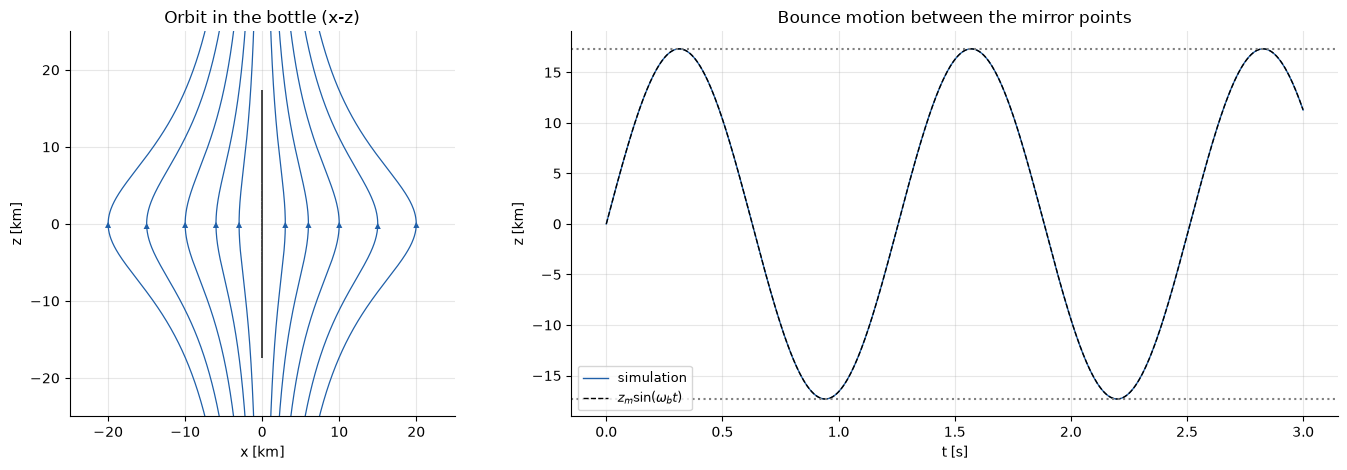

In [4]:
L_b, alpha0, v0 = 1e4, np.deg2rad(30), 1e5
Tc = gyroperiod(Q_E, M_P, 1e-5)
p0 = single_particle(v0=[v0*np.sin(alpha0), 0, v0*np.cos(alpha0)])
sim = BorisC(p0, bottle_field, dt=Tc/50, t_max=3.0, store_dt=Tc/10, relativistic=False)
h = sim.run()

z = h.r[:, 0, 2]
up = np.where((z[:-1] < 0) & (z[1:] >= 0))[0]                 # upward zero crossings
check("mirror point z_m [km]", z.max() / 1e3, L_b / np.tan(alpha0) / 1e3, 2e-2)
check("bounce period T_b [s]", np.diff(h.t[up]).mean(), 2*np.pi*L_b / (v0*np.sin(alpha0)), 2e-2)

B_loc = np.linalg.norm(bottle_field(h.r[:, 0], 0)[0], axis=1)
v_perp2 = np.sum(np.cross(h.v[:, 0], bottle_field(h.r[:, 0], 0)[0] / B_loc[:, None])**2, axis=1)
mu = M_P * v_perp2 / (2 * B_loc)
print(f"  μ conserved to {np.ptp(mu) / mu.mean():.1e} (relative peak-to-peak; r_L/L = {gyroradius(M_P, v0*np.sin(alpha0), Q_E, 1e-5)/L_b:.1e})")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.8), gridspec_kw={"width_ratios": [1, 1.6]})
plot_field_lines(bottle_field, history=h, projection="xz", length_unit=1e3, unit_label="km",
                 ax_lim=25, ax=a1, seed_points=bottle_seeds, title="Orbit in the bottle (x-z)")
t_th = np.linspace(0, h.t[-1], 400)
a2.plot(h.t, z / 1e3, color="#1f5fa8", lw=1, label="simulation")
a2.plot(t_th, L_b/np.tan(alpha0) * np.sin(v0*np.sin(alpha0)/L_b * t_th) / 1e3, "k--", lw=1,
        label=r"$z_m \sin(\omega_b t)$")
a2.axhline(L_b/np.tan(alpha0)/1e3, color="0.5", ls=":"); a2.axhline(-L_b/np.tan(alpha0)/1e3, color="0.5", ls=":")
a2.set_xlabel("t [s]"); a2.set_ylabel("z [km]"); a2.set_title("Bounce motion between the mirror points")
a2.legend(loc="lower left"); fig.tight_layout(); plt.show()

## 5. $\mathbf E\times\mathbf B$ drift

Adding a perpendicular electric field makes the guiding centre drift with
$$
\mathbf v_E = \frac{\mathbf E\times\mathbf B}{B^2},
$$
which depends on neither the charge, the mass nor the velocity. To show this, `random_ensemble` launches particles with random velocities. Protons and electrons have gyroradii that differ by $m_p/m_e \approx 1836$, yet every particle drifts with the same $\mathbf v_E$. The drift velocity is measured as the displacement over an integer number of gyroperiods.

  protons: mean drift v_y [m/s]        -49984  (theory -50000,  rel. err 3.3e-04)
  spread between particles: 2.7e-07,  |v_x| < 1.0e-02 m/s
  electrons: mean drift v_y [m/s]      -49984  (theory -50000,  rel. err 3.3e-04)
  spread between particles: 2.8e-07,  |v_x| < 9.3e-03 m/s


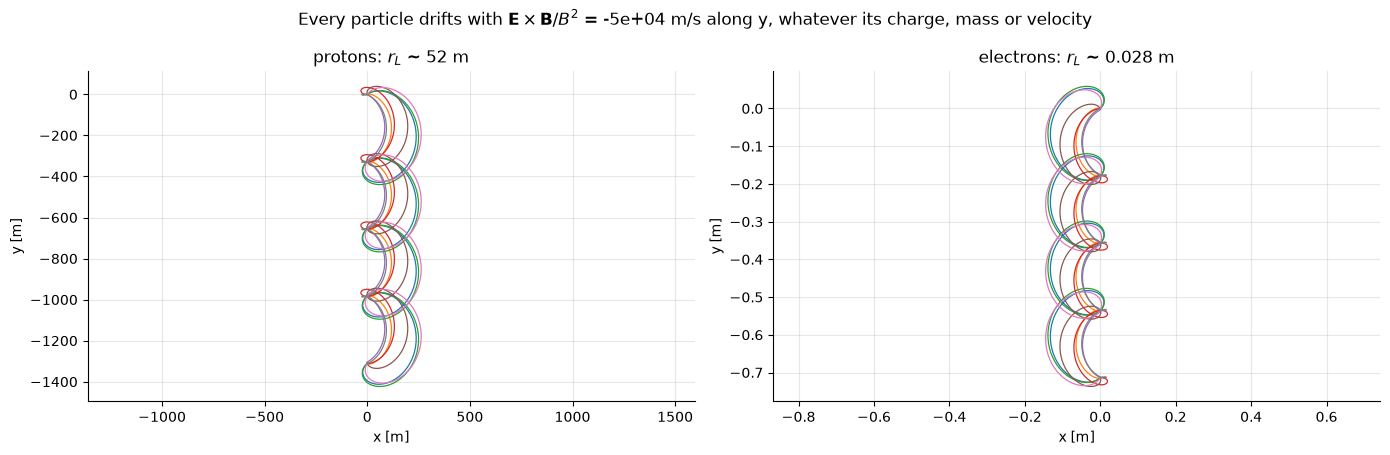

In [5]:
B0, E0 = 1e-5, np.array([0.5, 0.0, 0.0])                # 10 µT along z, 0.5 V/m along x
fEB = UniformEB(B=(0, 0, B0), E=E0)
vE = np.cross(E0, [0, 0, B0]) / B0**2                    # (0, -5e4, 0) m/s

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
for ax, (q, m, name) in zip(axes, [(Q_E, M_P, "protons"), (-Q_E, M_E, "electrons")]):
    Tc = gyroperiod(q, m, B0)
    ens = random_ensemble(8, q=q, m=m, v_max=1.5*abs(vE[1]), axes=(0, 1, 2), seed=4)
    h = BorisC(ens, fEB, dt=Tc/100, t_max=4*Tc, relativistic=False).run()
    v_drift = (h.r[-1] - h.r[0]) / (h.t[-1] - h.t[0])       # (N, 3), mean over 4 gyrations
    check(f"{name}: mean drift v_y [m/s]", v_drift[:, 1].mean(), vE[1], 1e-3)
    print(f"  spread between particles: {np.ptp(v_drift[:, 1]) / abs(vE[1]):.1e},"
          f"  |v_x| < {np.abs(v_drift[:, 0]).max():.1e} m/s")
    for pid in range(h.r.shape[1]):
        ax.plot(h.r[:, pid, 0], h.r[:, pid, 1], lw=0.9)
    ax.set_title(f"{name}: $r_L$ ~ {gyroradius(m, abs(vE[1]), q, B0):.2g} m")
    ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.set_aspect("equal", adjustable="datalim")
fig.suptitle(r"Every particle drifts with $\mathbf{E}\times\mathbf{B}/B^2$ = "
             f"{vE[1]:.0e} m/s along y, whatever its charge, mass or velocity")
fig.tight_layout(); plt.show()

## 6. Integrators

| integrator | scheme | order | properties |
|---|---|---|---|
| `BorisA` | Boris push (1970): rotation with $\mathbf t = \tan(\theta/2)\,\hat{\mathbf b}$ | 2 | exact rotation angle $\theta = qB\Delta t/(\gamma m)$ |
| `BorisB` | textbook Boris: $\mathbf t = (\theta/2)\,\hat{\mathbf b}$ | 2 | rotates by $2\arctan(\theta/2) < \theta$, so there is a phase lag |
| `BorisC` | Zenitani & Umeda (2018): exact $\cos\theta$, $\sin\theta$ rotation | 2 | exact phase, volume preserving |
| `RKnonrel` | Dormand–Prince RK45 on $\dot{\mathbf v} = (q/m)(\mathbf E + \mathbf v\times\mathbf B)$ | 5 | non-relativistic, fixed or adaptive step |
| `RKrel` | RK45 on $\dot{\mathbf v}$ including $\gamma$ and the $\mathbf v\cdot\mathbf E$ term | 5 | relativistic, fixed or adaptive step |

All integrators share `run()`. It takes `store_dt` (sampling interval of the stored history), `progress_every`, and an optional `live_plotter`.

**Boris family.** The magnetic rotation preserves $\lvert\mathbf u\rvert$ exactly, so a pure magnetic field never changes the energy, at any step size. The variants differ only in phase. For Boris-B the phase error per step is $\theta - 2\arctan(\theta/2)$. A deliberately coarse step, $\Delta t = T_c/20$, makes it visible. RK45 is accurate to high order but not symplectic, so its energy error grows secularly.

BorisA  phase error after 50 T_c: -5.116e-13 rad,  max |ΔE/E| = 0.0e+00
BorisB  phase error after 50 T_c: +2.546e+00 rad,  max |ΔE/E| = 2.8e-15
  Boris-B phase lag [rad]               2.5463  (theory  2.5463,  rel. err 2.3e-13)
BorisC  phase error after 50 T_c: -5.116e-13 rad,  max |ΔE/E| = 0.0e+00


RKrel   phase error after 50 T_c: -1.481e-02 rad,  max |ΔE/E| = 6.9e-04


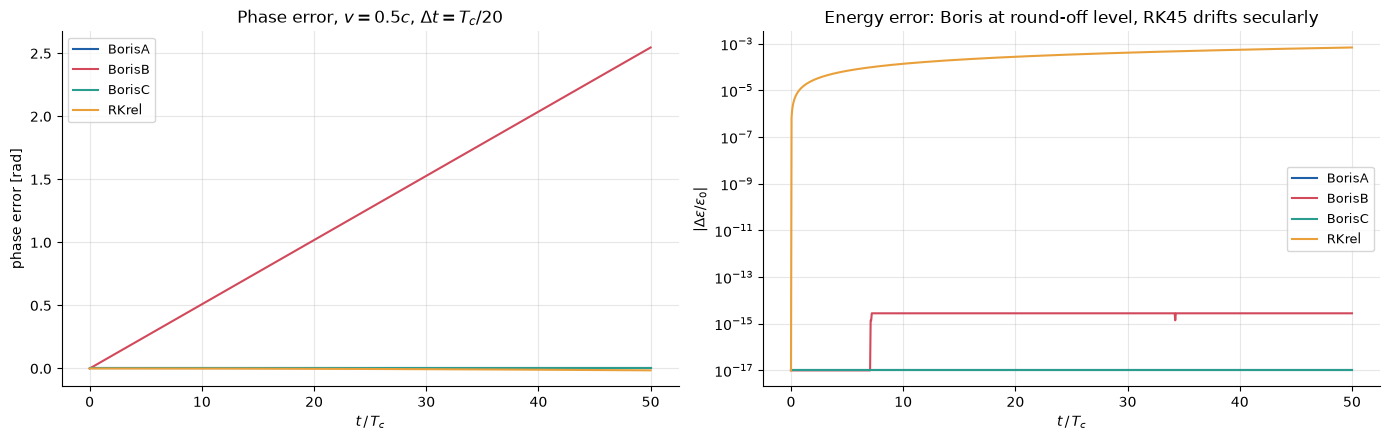

In [6]:
B0 = 1e-5
fB = UniformB(B=(0, 0, B0))
v0 = 0.5 * C
gamma0 = 1 / np.sqrt(1 - 0.5**2)
Tc = gamma0 * gyroperiod(Q_E, M_P, B0)                   # relativistic gyroperiod
dt, theta, t_max = Tc/20, 2*np.pi/20, 50*Tc

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.5))
for cls, col in [(BorisA, "#1f5fa8"), (BorisB, "#d1495b"), (BorisC, "#2a9d8f"), (RKrel, "#e9a03b")]:
    sim = cls(single_particle(v0=[0, v0, 0]), fB, dt=dt, t_max=t_max, relativistic=True)
    h = sim.run()
    phase = np.unwrap(np.arctan2(h.v[:, 0, 1], h.v[:, 0, 0]))
    dphi = phase - phase[0] + 2*np.pi * h.t / Tc         # phase error relative to exact gyration
    dE = np.abs(relative_energy_error(h, sim.state.m)[:, 0])
    name = cls.__name__
    a1.plot(h.t / Tc, dphi, color=col, label=name)
    a2.semilogy(h.t / Tc, dE + 1e-17, color=col, label=name)
    print(f"{name:7s} phase error after 50 T_c: {dphi[-1]:+.3e} rad,  max |ΔE/E| = {dE.max():.1e}")
    if name == "BorisB":
        check("Boris-B phase lag [rad]", dphi[-1], (len(h.t) - 1) * (theta - 2*np.arctan(theta/2)), 1e-3)
    elif name in ("BorisA", "BorisC"):
        assert abs(dphi[-1]) < 1e-8 and dE.max() < 1e-12

a1.set_xlabel(r"$t\,/\,T_c$"); a1.set_ylabel("phase error [rad]"); a1.legend()
a1.set_title(r"Phase error, $v = 0.5c$, $\Delta t = T_c/20$")
a2.set_xlabel(r"$t\,/\,T_c$"); a2.set_ylabel(r"$|\Delta\varepsilon/\varepsilon_0|$"); a2.legend()
a2.set_title("Energy error: Boris at round-off level, RK45 drifts secularly")
fig.tight_layout(); plt.show()

**Relativistic vs non-relativistic RK.** At $v = 0.5c$ the non-relativistic equation of motion overestimates the gyrofrequency by a factor of $\gamma = 1.155$ and underestimates the gyroradius by the same factor. Only `RKrel` reproduces $r_L = \gamma m v/(qB)$.

  RKnonrel radius [m]                   1.5649e+05  (theory  1.5649e+05,  rel. err 1.2e-05)
  RKrel radius [m]                      1.807e+05  (theory  1.807e+05,  rel. err 1.2e-11)


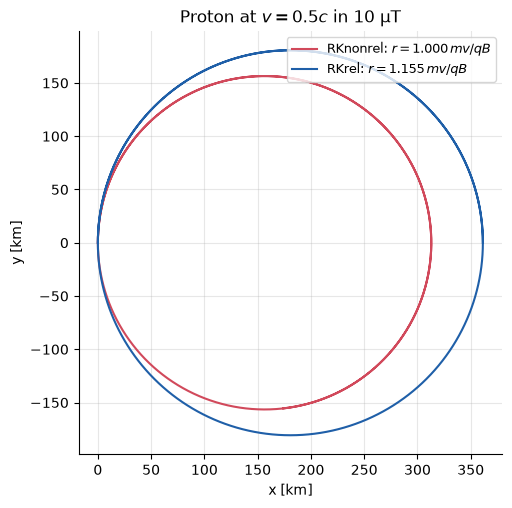

In [7]:
fig, ax = plt.subplots(figsize=(6, 5.5))
for cls, g, col in [(RKnonrel, 1.0, "#d1495b"), (RKrel, gamma0, "#1f5fa8")]:
    sim = cls(single_particle(v0=[0, v0, 0]), fB, dt=Tc/200, t_max=1.5*Tc, relativistic=(g > 1))
    h = sim.run()
    x, y = h.r[:, 0, 0], h.r[:, 0, 1]
    check(f"{cls.__name__} radius [m]", 0.5*(x.max() - x.min()), g * gyroradius(M_P, v0, Q_E, B0), 1e-4)
    ax.plot(x / 1e3, y / 1e3, color=col, label=f"{cls.__name__}: $r = {g:.3f}\\,mv/qB$")
ax.set_aspect("equal"); ax.set_xlabel("x [km]"); ax.set_ylabel("y [km]")
ax.set_title(r"Proton at $v = 0.5c$ in 10 µT"); ax.legend(loc="upper right"); plt.show()

## 7. Cyclotron resonance

`CyclotronWaveField` adds an electric field $E_y = E_0\sin\omega_c t$ that oscillates exactly at the gyrofrequency. A linearly polarised wave is the sum of two circularly polarised waves of amplitude $E_0/2$. One of them co-rotates with the particle and pushes it in phase on every orbit, so for a particle starting at rest
$$
v_\perp(t) \simeq \frac{qE_0}{2m}\,t,\qquad K(t) \simeq \frac{(qE_0 t)^2}{8m}.
$$
Off resonance the push drifts out of phase and the energy only beats. That case is shown with a `CustomField` built through the vector API: a time-dependent, spatially uniform wave detuned by 10 %.

  dv⊥/dt [m/s²]                         47873  (theory  47894,  rel. err 4.5e-04)


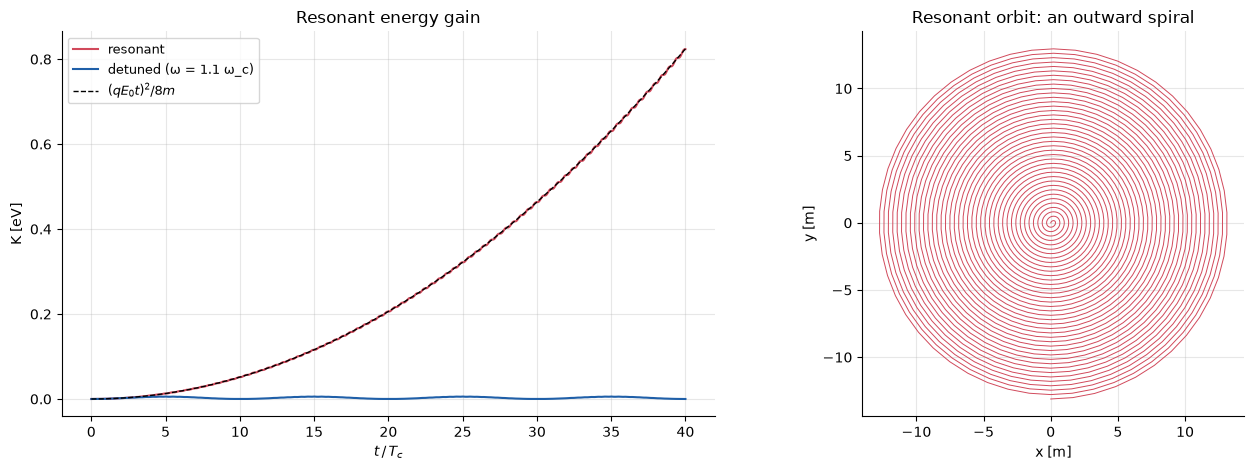

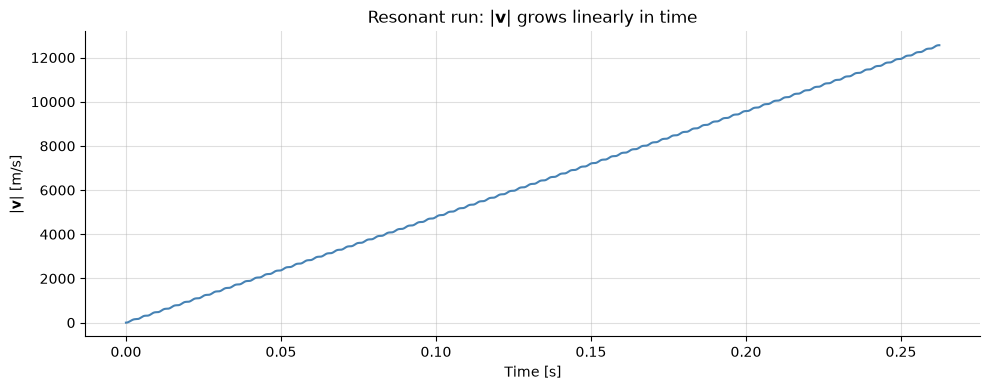

In [8]:
B0, E0 = 1e-5, 1e-3
cw = CyclotronWaveField(B=(0, 0, B0), q=Q_E, m=M_P, E_amp=E0)
Tc = 2*np.pi / cw.omega_c

def detuned_wave(r, t, w=1.1*cw.omega_c):
    B = np.tile([0.0, 0.0, B0], (len(r), 1))
    E = np.zeros_like(B); E[:, 1] = E0 * np.sin(w * t)
    return B, E
off = CustomField(detuned_wave, vector_api=True, is_uniform=True, is_static=False)

runs = {}
for name, field in [("resonant", cw), ("detuned (ω = 1.1 ω_c)", off)]:
    runs[name] = BorisC(single_particle(), field, dt=Tc/100, t_max=40*Tc, store_dt=Tc/50,
                        relativistic=False).run()

h = runs["resonant"]
v_perp = np.hypot(h.v[:, 0, 0], h.v[:, 0, 1])
late = h.t > 5*Tc
check("dv⊥/dt [m/s²]", np.polyfit(h.t[late], v_perp[late], 1)[0], Q_E*E0/(2*M_P), 1e-2)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.8))
for (name, hh), col in zip(runs.items(), ["#d1495b", "#1f5fa8"]):
    K = hh.kinetic_energy(np.array([M_P]), relativistic=False)[:, 0] / Q_E
    a1.plot(hh.t / Tc, K, color=col, label=name)
a1.plot(h.t / Tc, (Q_E*E0*h.t)**2 / (8*M_P) / Q_E, "k--", lw=1, label=r"$(qE_0t)^2/8m$")
a1.set_xlabel(r"$t\,/\,T_c$"); a1.set_ylabel("K [eV]"); a1.set_title("Resonant energy gain"); a1.legend()
a2.plot(h.r[:, 0, 0], h.r[:, 0, 1], color="#d1495b", lw=0.7)
a2.set_aspect("equal"); a2.set_xlabel("x [m]"); a2.set_ylabel("y [m]")
a2.set_title("Resonant orbit: an outward spiral")
fig.tight_layout(); plt.show()

plot_speed(h, relativistic=False, title=r"Resonant run: $|\mathbf{v}|$ grows linearly in time")
plt.show()

## 8. Trapped particles in the Earth's dipole

Radiation-belt particles combine three periodic motions with well-separated timescales:
1. **Gyration** about the field line, with period $T_c$.
2. **Bounce** between the mirror points $\pm\lambda_m$, where $\cos^6\lambda_m = \sin^2\alpha_{eq}\sqrt{1+3\sin^2\lambda_m}$. Integrating $ds/v_\parallel$ along the dipole line $r = LR_E\cos^2\lambda$ gives
$$
\tau_b = \frac{4LR_E}{v}\int_0^{\lambda_m}\frac{\cos\lambda\,\sqrt{1+3\sin^2\lambda}}{\sqrt{1-\sin^2\alpha_{eq}\,B(\lambda)/B_{eq}}}\,d\lambda \;\approx\; \frac{4LR_E}{v}\,(1.30 - 0.56\sin\alpha_{eq}).
$$
3. **Gradient–curvature drift** around the Earth, protons westward and electrons eastward, with
$$
\omega_d \approx \frac{3L\gamma m v^2}{q B_E R_E^2}\,(0.35 + 0.15\sin\alpha_{eq}),\qquad B_E R_E^2 = \frac{M}{R_E}.
$$

The approximate forms are those of Hamlin et al. (1961), accurate to about 2 %. The guiding-centre theory behind them also neglects corrections of order $r_L/LR_E$, which is about 2 % for the example below. The drift check therefore uses a 5 % tolerance. Lowering the energy makes the measured drift converge to the formula.

The example is a 20 MeV proton at $L = 3$ with equatorial pitch angle $\alpha_{eq} = 45°$, set up with `dipole_initial_conditions(r0, v0)`. The tilt of the dipole is a rotation about $\hat{\mathbf x}$, so the start point $3R_E\,\hat{\mathbf x}$ lies on the magnetic equator. Azimuth and latitude are measured in the magnetic frame. One full drift orbit is integrated with `BorisC`.

In [9]:
L, W_MeV, alpha_eq = 3.0, 20.0, np.deg2rad(45)
gamma = 1 + W_MeV*1e6*Q_E / (M_P*C**2)
v = C * np.sqrt(1 - 1/gamma**2)

r0 = np.array([L*R_EARTH, 0.0, 0.0])
b_hat = dip(r0, 0)[0][0]; b_hat /= np.linalg.norm(b_hat)
e_perp = np.cross(b_hat, [1.0, 0.0, 0.0]); e_perp /= np.linalg.norm(e_perp)
v0 = v * (np.sin(alpha_eq)*e_perp + np.cos(alpha_eq)*b_hat)
trapped = dipole_initial_conditions(r0=r0, v0=v0)

B_eq  = dip.B_equator(L*R_EARTH)
Tc    = 2*np.pi*gamma*M_P / (Q_E*B_eq)
from scipy.integrate import quad
from scipy.optimize import brentq
s2 = np.sin(alpha_eq)**2
B_rel = lambda lam: np.sqrt(1 + 3*np.sin(lam)**2) / np.cos(lam)**6       # B(λ)/B_eq along the line
lam_m = brentq(lambda lam: 1 - s2*B_rel(lam), 0, np.pi/2 - 1e-6)         # mirror latitude
tau_b = 4*L*R_EARTH/v * quad(lambda lam: np.cos(lam)*np.sqrt(1 + 3*np.sin(lam)**2)
                             / np.sqrt(max(1 - s2*B_rel(lam), 1e-300)), 0, lam_m, limit=200)[0]
w_d   = 3*L*gamma*M_P*v**2*R_EARTH / (Q_E*DIPOLE_MOMENT) * (0.35 + 0.15*np.sin(alpha_eq))
print(f"γ = {gamma:.4f},  v = {v/C:.3f} c,  B_eq = {B_eq*1e9:.0f} nT,"
      f"  r_L = {gyroradius(gamma*M_P, v*np.sin(alpha_eq), Q_E, B_eq)/R_EARTH:.3f} R_E")
print(f"mirror latitude λ_m = {np.degrees(lam_m):.1f}°,  Hamlin τ_b = {4*L*R_EARTH/v*(1.30 - 0.56*np.sin(alpha_eq)):.3f} s")
print(f"T_c = {Tc*1e3:.1f} ms   τ_b = {tau_b:.3f} s   τ_d ≈ {2*np.pi/w_d:.1f} s")

sim = BorisC(trapped.copy(), dip, dt=Tc/40, t_max=1.05*2*np.pi/w_d, store_dt=Tc/8)
h_dip = sim.run()
r, n_gyr = h_dip.r[:, 0], 8                              # samples per gyration

def smooth(a):                                           # average over one gyration ≈ guiding centre
    return np.convolve(a, np.ones(n_gyr)/n_gyr, mode="same")

e_b = np.cross(dip.axis, [1.0, 0.0, 0.0])
lat = smooth(r @ dip.axis) / R_EARTH                     # height above the magnetic equator
phi = np.unwrap(np.arctan2(r @ e_b, r[:, 0]))            # magnetic azimuth (eastward positive)
up = np.where((lat[:-1] < 0) & (lat[1:] >= 0))[0][1:-1]
dE = relative_energy_error(h_dip, sim.state.m)[:, 0]

check("bounce period τ_b [s]", np.diff(h_dip.t[up]).mean(), tau_b, 1e-2)
check("drift rate |ω_d| [rad/s]", abs(np.polyfit(h_dip.t, phi, 1)[0]), w_d, 5e-2)
assert np.polyfit(h_dip.t, phi, 1)[0] < 0                # protons drift westward
assert np.abs(dE).max() < 1e-10
print(f"  max |ΔE/E| = {np.abs(dE).max():.1e}")

B_loc = dip(r, 0)[0]; Bm = np.linalg.norm(B_loc, axis=1)
p_perp2 = (gamma*M_P)**2 * np.sum(np.cross(h_dip.v[:, 0], B_loc/Bm[:, None])**2, axis=1)
mu = smooth(p_perp2 / (2*gamma*M_P*Bm))[n_gyr:-n_gyr]
print(f"  first invariant μ: gyro-averaged variation {np.ptp(mu)/mu.mean():.1%}")

γ = 1.0213,  v = 0.203 c,  B_eq = 1098 nT,  r_L = 0.066 R_E
mirror latitude λ_m = 23.1°,  Hamlin τ_b = 1.136 s
T_c = 61.0 ms   τ_b = 1.114 s   τ_d ≈ 46.6 s


  bounce period τ_b [s]                 1.1103  (theory  1.114,  rel. err 3.3e-03)
  drift rate |ω_d| [rad/s]              0.13966  (theory  0.13476,  rel. err 3.6e-02)
  max |ΔE/E| = 1.0e-14
  first invariant μ: gyro-averaged variation 4.7%


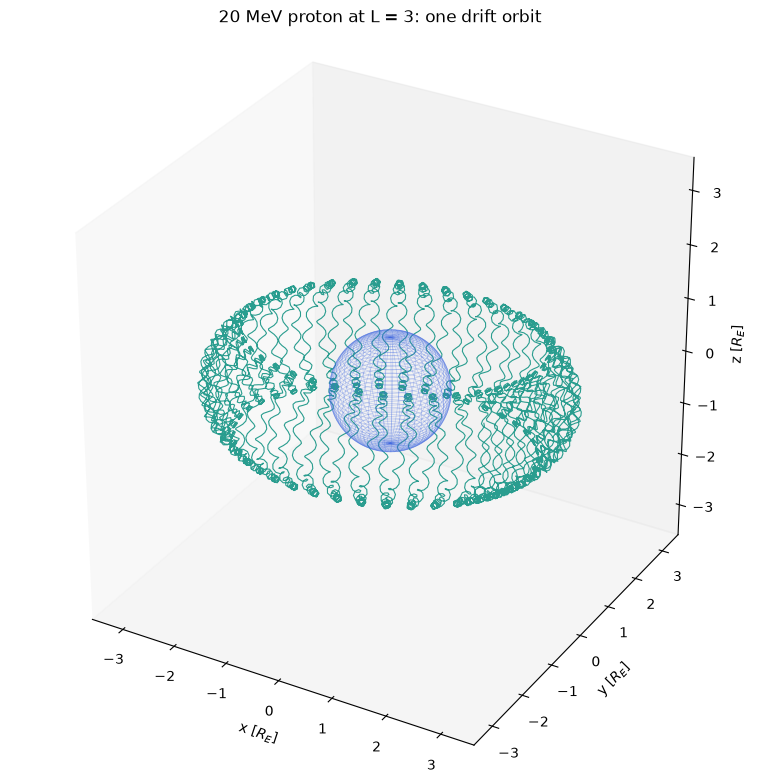

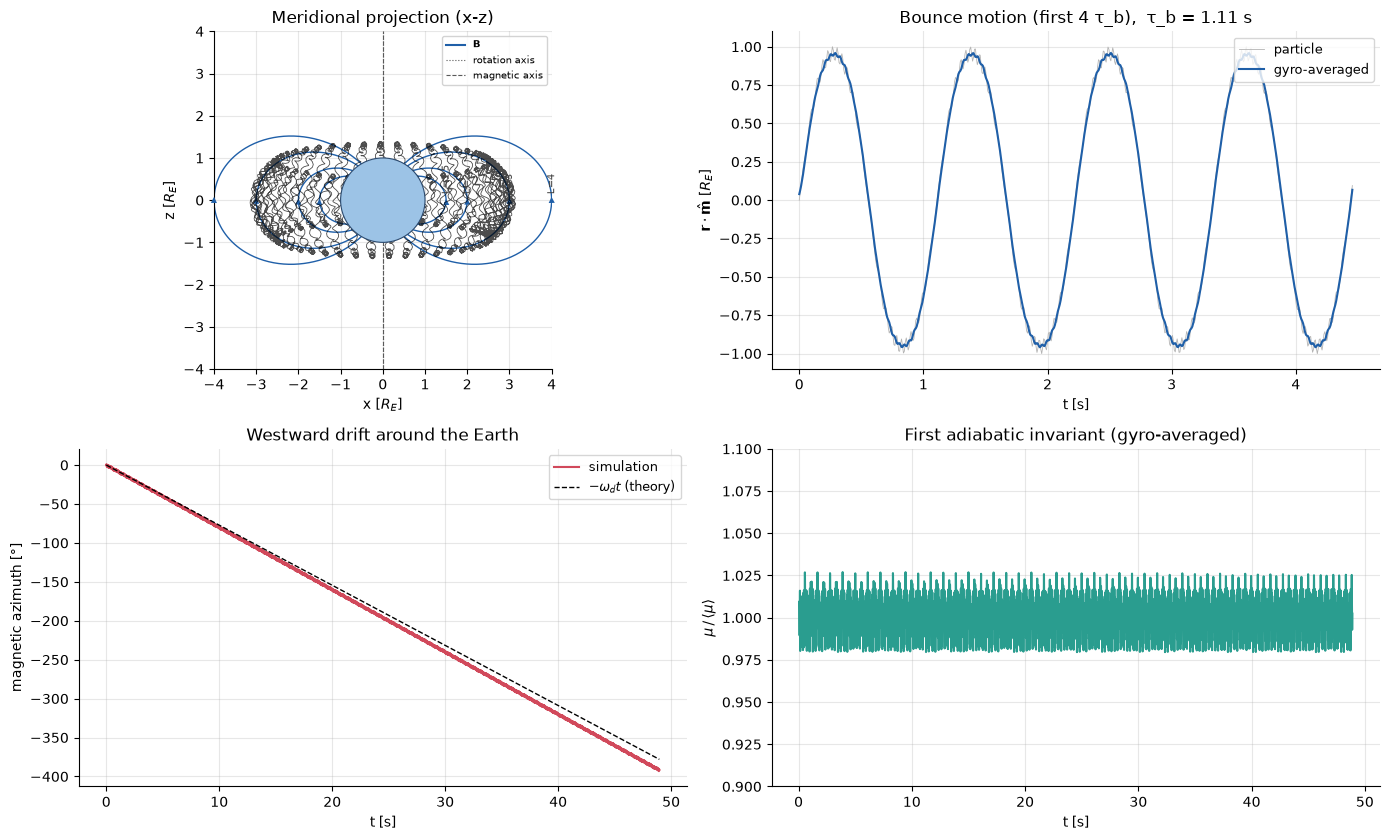

In [10]:
fig, ax3 = plot_trajectory_3d(h_dip, earth_sphere=True, ax_lim=3.6, color="#2a9d8f", title="20 MeV proton at L = 3: one drift orbit")
plt.show()

fig, ax = plt.subplots(2, 2, figsize=(14, 8.5))
plot_field_lines(dip, history=h_dip, projection="xz", length_unit=R_EARTH, unit_label=r"$R_E$",
                 ax_lim=4, ax=ax[0, 0], L_shells=(1.5, 2, 3, 4), title="Meridional projection (x-z)")
mask = h_dip.t < 4*tau_b
ax[0, 1].plot(h_dip.t[mask], (r @ dip.axis)[mask] / R_EARTH, color="0.7", lw=0.6, label="particle")
ax[0, 1].plot(h_dip.t[mask], lat[mask], color="#1f5fa8", label="gyro-averaged")
ax[0, 1].set_xlabel("t [s]"); ax[0, 1].set_ylabel(r"$\mathbf{r}\cdot\hat{\mathbf{m}}$ [$R_E$]")
ax[0, 1].set_title(f"Bounce motion (first 4 τ_b),  τ_b = {tau_b:.2f} s"); ax[0, 1].legend(loc="upper right")
ax[1, 0].plot(h_dip.t, np.degrees(phi), color="#d1495b", label="simulation")
ax[1, 0].plot(h_dip.t, np.degrees(phi[0] - w_d*h_dip.t), "k--", lw=1, label=r"$-\omega_d t$ (theory)")
ax[1, 0].set_xlabel("t [s]"); ax[1, 0].set_ylabel("magnetic azimuth [°]")
ax[1, 0].set_title("Westward drift around the Earth"); ax[1, 0].legend()
ax[1, 1].plot(h_dip.t[n_gyr:-n_gyr], mu / mu.mean(), color="#2a9d8f")
ax[1, 1].set_xlabel("t [s]"); ax[1, 1].set_ylabel(r"$\mu\,/\,\langle\mu\rangle$")
ax[1, 1].set_title("First adiabatic invariant (gyro-averaged)"); ax[1, 1].set_ylim(0.9, 1.1)
fig.tight_layout(); plt.show()

**Adaptive step size.** `RKrel(adaptive=True)` controls the local error with `rtol` and `atol`. Along a bounce orbit the field, and with it the gyrofrequency, varies by a factor of a few. The accepted step size follows $\Delta t \propto 1/B$, while a fixed-step scheme has to use the smallest step everywhere.

2085 accepted steps; dt ranges over ×3.60, |B| over ×1.98;  corr(dt, 1/B) = 0.845
max |ΔE/E| (RK45, rtol=1e-7): 8.6e-06


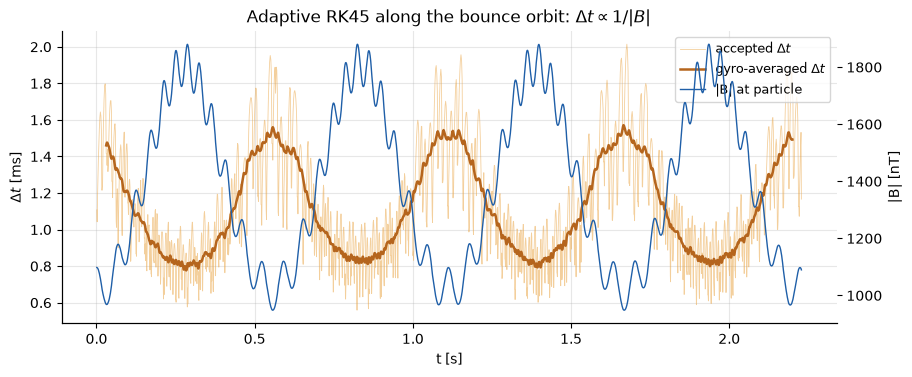

In [11]:
sim_rk = RKrel(trapped.copy(), dip, dt=Tc/40, t_max=2*tau_b, adaptive=True, rtol=1e-7, atol=1e-3)
h_rk = sim_rk.run()                                     # store_dt=None: every accepted step is stored
dt_acc = np.diff(h_rk.t)
B_rk = np.linalg.norm(dip(h_rk.r[:-1, 0], 0)[0], axis=1)
print(f"{len(dt_acc)} accepted steps; dt ranges over ×{dt_acc.max()/dt_acc.min():.2f}, "
      f"|B| over ×{B_rk.max()/B_rk.min():.2f};  corr(dt, 1/B) = {np.corrcoef(dt_acc, 1/B_rk)[0, 1]:.3f}")
print(f"max |ΔE/E| (RK45, rtol=1e-7): {np.abs(relative_energy_error(h_rk, sim_rk.state.m)).max():.1e}")

fig, a1 = plt.subplots(figsize=(10, 3.8))
a1.plot(h_rk.t[1:], dt_acc * 1e3, color="#e9a03b", lw=0.6, alpha=0.5, label=r"accepted $\Delta t$")
k = 40                                                   # ≈ one gyration of steps
a1.plot(h_rk.t[1:][k//2:-k//2], np.convolve(dt_acc, np.ones(k)/k, "same")[k//2:-k//2] * 1e3,
        color="#b5651d", lw=1.8, label=r"gyro-averaged $\Delta t$")
a1.set_xlabel("t [s]"); a1.set_ylabel(r"$\Delta t$ [ms]")
a2 = a1.twinx(); a2.grid(False)
a2.plot(h_rk.t[1:], B_rk * 1e9, color="#1f5fa8", lw=1, label="|B| at particle")
a2.set_ylabel("|B| [nT]")
a1.legend(handles=a1.get_lines() + a2.get_lines(), loc="upper right")
a1.set_title(r"Adaptive RK45 along the bounce orbit: $\Delta t \propto 1/|B|$"); plt.show()

## 9. Radiation

**Power.** An accelerated charge radiates the Liénard power
$$
P = \frac{q^2\gamma^6}{6\pi\varepsilon_0 c^3}\left[\,a^2 - \frac{\lvert\mathbf v\times\mathbf a\rvert^2}{c^2}\right]
\;\xrightarrow{\ \text{circular}\ }\; \frac{q^2\gamma^4 a^2}{6\pi\varepsilon_0 c^3},\qquad a = v\,\omega_c .
$$
`radiated_power` evaluates this formula along the stored orbit, using the acceleration computed from the Lorentz force. `total_radiated_energy` integrates it over time.

In [12]:
B0 = 1e-5
fB = UniformB(B=(0, 0, B0))
for name, q, m, beta in [("proton,   β = 0.01", Q_E, M_P, 0.01), ("electron, β = 0.9 ", -Q_E, M_E, 0.9)]:
    g = 1 / np.sqrt(1 - beta**2)
    w = abs(q) * B0 / (g * m)
    sim = BorisC(single_particle(q=q, m=m, v0=[0, beta*C, 0]), fB, dt=2*np.pi/w/400,
                 t_max=10 * 2*np.pi/w, store_dt=2*np.pi/w/100)
    h = sim.run()
    P = radiated_power(h, sim.state.q, sim.state.m, fB)[:, 0]
    P_th = q**2 * g**4 * (beta*C*w)**2 / (6*np.pi*EPS0*C**3)
    print(name)
    check("    Liénard power P [W]", P.mean(), P_th, 1e-6)
    check("    radiated energy over 10 T_c [J]", total_radiated_energy(h, sim.state.q, sim.state.m, fB)[0],
          P_th * h.t[-1], 1e-6)

proton,   β = 0.01
      Liénard power P [W]               4.7078e-35  (theory  4.7078e-35,  rel. err 2.6e-13)
      radiated energy over 10 T_c [J]   3.0882e-36  (theory  3.0882e-36,  rel. err 2.6e-13)


electron, β = 0.9 
      Liénard power P [W]               6.7659e-24  (theory  6.7659e-24,  rel. err 2.1e-14)
      radiated energy over 10 T_c [J]   5.5451e-28  (theory  5.5451e-28,  rel. err 2.1e-14)


**Spectra.** `spectrum_fft` Fourier-transforms the transverse acceleration seen by an observer in direction $\hat{\mathbf n}$. This is fast and correct for slow particles: a single line at $f_c$ whose width shrinks as $1/T_\text{obs}$. `spectrum_retarded` evaluates Jackson's retarded-time integral (Eq. 14.67),
$$
\frac{d^2I}{d\omega\,d\Omega} \propto \omega^2\left\lvert\int \hat{\mathbf n}\times(\hat{\mathbf n}\times\boldsymbol\beta)\, e^{\,i\omega(t - \hat{\mathbf n}\cdot\mathbf r/c)}\,dt\right\rvert^2 .
$$
The retardation phase turns relativistic gyration into **cyclotron–synchrotron harmonics** $n\,\omega_c$. Seen in the orbital plane, the harmonics extend to about $\gamma^3$ when $\beta \to 1$, and are weak at low $\beta$, where harmonic $n$ is suppressed by about $\beta^{2(n-1)}$.

  FFT peak frequency / f_c              0.99917  (theory  1,  rel. err 8.3e-04)


β = 0.3: harmonic powers P_n/P_1 (n = 2..5) = 0.34, 0.083, 0.018, 0.0036
  β = 0.3: fundamental at ω/ω_c         1.0014  (theory  1,  rel. err 1.4e-03)


β = 0.9: harmonic powers P_n/P_1 (n = 2..5) = 1.8, 2.5, 3, 3.4
  β = 0.9: fundamental at ω/ω_c         1.0014  (theory  1,  rel. err 1.4e-03)


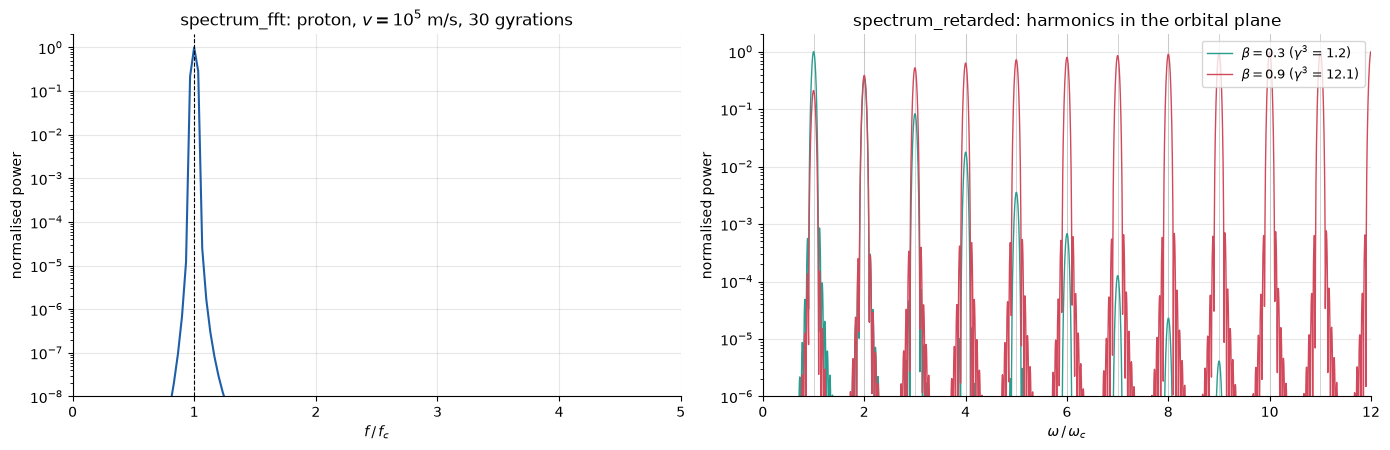

In [13]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.6))

# FFT: non-relativistic proton, line at f_c
Tc = gyroperiod(Q_E, M_P, B0)
h = BorisC(single_particle(v0=[0, 1e5, 0]), fB, dt=Tc/200, t_max=30*Tc, store_dt=Tc/40).run()
f, p = spectrum_fft(h, store_dt_warn_period=Tc)
check("FFT peak frequency / f_c", f[np.argmax(p)] * Tc, 1.0, 1/30)
a1.semilogy(f*Tc, p/p.max(), color="#1f5fa8")
a1.axvline(1, color="k", ls="--", lw=0.8)
a1.set_xlim(0, 5); a1.set_ylim(1e-8, 2)
a1.set_xlabel(r"$f\,/\,f_c$"); a1.set_ylabel("normalised power")
a1.set_title(r"spectrum_fft: proton, $v = 10^5$ m/s, 30 gyrations")

# Retarded integral: electrons at β = 0.3 and 0.9, observer in the orbital plane
n_hat = np.array([1.0, 0.0, 0.0])
for beta, col in [(0.3, "#2a9d8f"), (0.9, "#d1495b")]:
    g = 1 / np.sqrt(1 - beta**2); w = Q_E*B0/(g*M_E); T = 2*np.pi/w
    h = BorisC(single_particle(q=-Q_E, m=M_E, v0=[0, beta*C, 0]), fB, dt=T/400,
               t_max=20*T, store_dt=T/200).run()
    omegas = np.linspace(0.05, 12, 2400) * w
    f, p = spectrum_retarded(h, omega_array=omegas, observer=n_hat)
    a2.semilogy(omegas/w, p/p.max(), color=col, lw=1, label=rf"$\beta = {beta}$ ($\gamma^3$ = {g**3:.1f})")
    peaks = [p[np.abs(omegas/w - n) < 0.25].max() for n in range(1, 6)]
    print(f"β = {beta}: harmonic powers P_n/P_1 (n = 2..5) = " + ", ".join(f"{x/peaks[0]:.2g}" for x in peaks[1:]))
    check(f"β = {beta}: fundamental at ω/ω_c", omegas[np.argmax(np.where(omegas/w < 1.5, p, 0))]/w, 1.0, 1e-2)
for n in range(1, 13):
    a2.axvline(n, color="0.8", lw=0.6, zorder=0)
a2.set_xlim(0, 12); a2.set_ylim(1e-6, 2)
a2.set_xlabel(r"$\omega\,/\,\omega_c$"); a2.set_ylabel("normalised power")
a2.set_title("spectrum_retarded: harmonics in the orbital plane"); a2.legend(loc="upper right")
fig.tight_layout(); plt.show()

## 10. Ensembles and thermal spectra

There are three ensemble factories:
- `random_ensemble`: uniform random velocity components (used in Section 5).
- `maxwellian_ensemble(N, T)`: each component is Gaussian with $\sigma = \sqrt{kT/m}$.
- `relativistic_thermal_ensemble(N, θ)`: Maxwell–Jüttner distribution with $\theta = kT/mc^2$,
$$
f(\gamma) = \frac{\gamma^2\beta}{\theta\,K_2(1/\theta)}\,e^{-\gamma/\theta},\qquad \langle\gamma\rangle = 3\theta + \frac{K_1(1/\theta)}{K_2(1/\theta)} .
$$

`ensemble_spectrum` adds the single-particle spectra incoherently, which is the right sum for uncorrelated particles. A non-relativistic thermal plasma radiates a single sharp line, because $\omega_c$ does not depend on the speed. In a relativistic plasma each particle radiates at $\omega_c/\gamma$, so the spread in $\gamma$ broadens the line into a continuum below $f_c$.

  Maxwell–Jüttner ⟨γ⟩                   2.0555  (theory  2.0512,  rel. err 2.1e-03)
  Maxwellian σ_v [m/s]                  90446  (theory  90854,  rel. err 4.5e-03)


  Maxwellian protons: peak f / f_c      0.99834  (theory  1,  rel. err 1.7e-03)


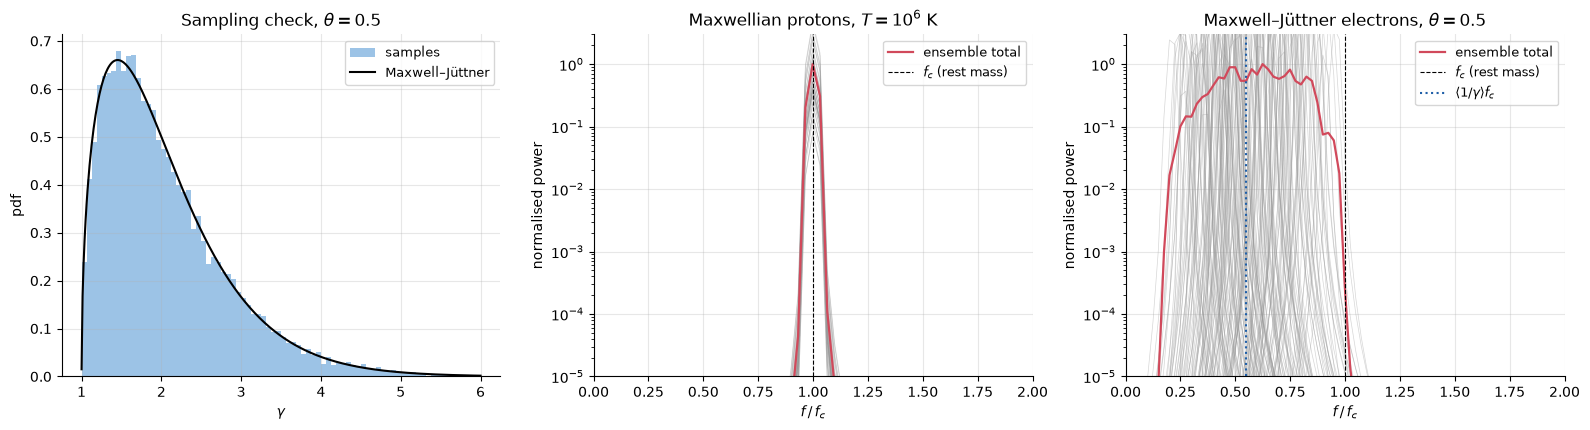

In [14]:
from scipy.special import kn

theta = 0.5
mj = relativistic_thermal_ensemble(20000, theta_e=theta, m=M_E, q=-Q_E, seed=1)
g_s = mj.gamma()
check("Maxwell–Jüttner ⟨γ⟩", g_s.mean(), 3*theta + kn(1, 1/theta)/kn(2, 1/theta), 1e-2)
mb = maxwellian_ensemble(20000, T=1e6, m=M_P, seed=1)
check("Maxwellian σ_v [m/s]", mb.v.std(), np.sqrt(K_B*1e6/M_P), 1e-2)

B0 = 1e-5
fB = UniformB(B=(0, 0, B0))
Tp, Te = gyroperiod(Q_E, M_P, B0), gyroperiod(Q_E, M_E, B0)
h_mb = BorisC(maxwellian_ensemble(40, T=1e6, m=M_P, seed=2), fB, dt=Tp/100, t_max=30*Tp,
              store_dt=Tp/20, relativistic=False).run()
h_mj = BorisC(relativistic_thermal_ensemble(150, theta_e=theta, m=M_E, q=-Q_E, seed=2), fB,
              dt=Te/100, t_max=40*Te, store_dt=Te/20).run()
f_mb, P_mb, ind_mb = ensemble_spectrum(h_mb)
f_mj, P_mj, ind_mj = ensemble_spectrum(h_mj)
check("Maxwellian protons: peak f / f_c", f_mb[np.argmax(P_mb)] * Tp, 1.0, 1/30)

fig, (a0, a1, a2) = plt.subplots(1, 3, figsize=(16, 4.4))
gg = np.linspace(1.0001, 6, 400)
a0.hist(g_s, bins=80, range=(1, 6), density=True, color="#9cc3e6", label="samples")
a0.plot(gg, gg**2*np.sqrt(1 - 1/gg**2)*np.exp(-gg/theta)/(theta*kn(2, 1/theta)), "k", label="Maxwell–Jüttner")
a0.set_xlabel(r"$\gamma$"); a0.set_ylabel("pdf"); a0.set_title(rf"Sampling check, $\theta = {theta}$"); a0.legend()
for ax, f, P, ind, T, ttl in [(a1, f_mb, P_mb, ind_mb, Tp, r"Maxwellian protons, $T = 10^6$ K"),
                              (a2, f_mj, P_mj, ind_mj, Te, rf"Maxwell–Jüttner electrons, $\theta = {theta}$")]:
    for p in ind:
        ax.semilogy(f*T, p/P.max(), color="0.6", lw=0.5, alpha=0.4)
    ax.semilogy(f*T, P/P.max(), color="#d1495b", lw=1.6, label="ensemble total")
    ax.axvline(1, color="k", ls="--", lw=0.8, label=r"$f_c$ (rest mass)")
    ax.set_xlim(0, 2); ax.set_ylim(1e-5, 3)
    ax.set_xlabel(r"$f\,/\,f_c$"); ax.set_ylabel("normalised power"); ax.set_title(ttl); ax.legend(loc="upper right")
a2.axvline((1/g_s).mean(), color="#1f5fa8", ls=":", label=r"$\langle 1/\gamma\rangle f_c$"); a2.legend(loc="upper right")
fig.tight_layout(); plt.show()

## 11. Overview figure and animations

`plot_overview` summarises a run in six panels:
- the position in two projections;
- the velocity hodograph in two projections, with a highlighted trail of the last few gyrations;
- the field lines with the orbit overlaid;
- the emission spectrum.

`make_overview_gif` animates the same layout. The FFT spectrum is recomputed every few frames from the orbit observed so far (red), against the final spectrum (grey). As the observation window grows, the lines narrow and rise out of the window side-lobes. `make_panel_gif` animates any single panel. For a time-dependent uniform field, the arrows of the field panel evolve with the field. The retarded-integral spectrum is expensive, so it is only ever drawn as the final result.

The example is the trapped proton of Section 8, re-run over five bounce periods.

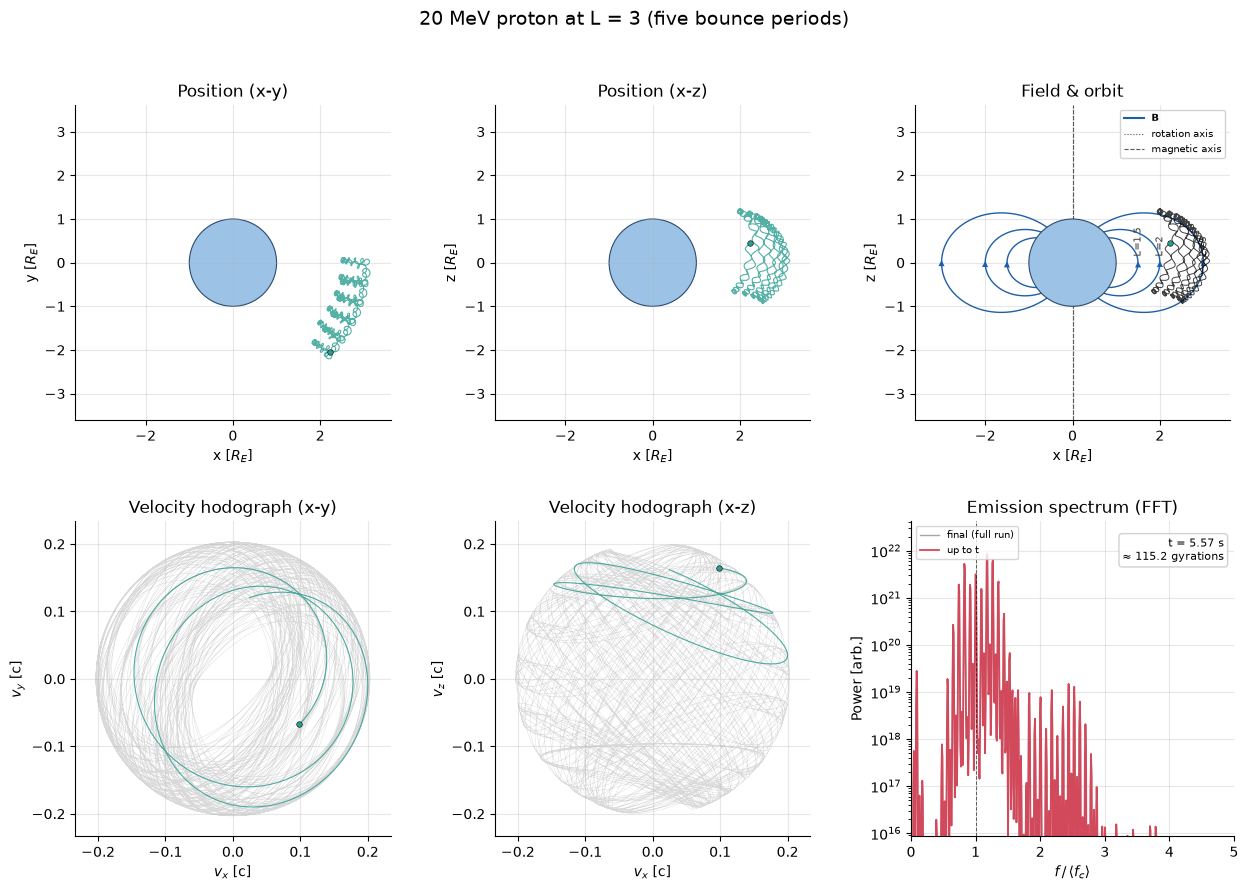

Saved: overview.gif


Saved: trajectory.gif


Saved: cyclotron.gif


Saved: spectrum.gif


In [15]:
sim = BorisC(trapped.copy(), dip, dt=Tc/40, t_max=5*tau_b, store_dt=Tc/10)
h_ov = sim.run()
kw = dict(q=sim.state.q, m=sim.state.m, length_unit=R_EARTH, unit_label=r"$R_E$",
          normalize_v=True, field_components=("B",))

fig = plot_overview(h_ov, dip, title="20 MeV proton at L = 3 (five bounce periods)", **kw)
fig.savefig("overview.png", dpi=110, bbox_inches="tight"); plt.show()

make_overview_gif(h_ov, dip, filename="overview.gif", fps=12, n_frames=100, dpi=60,
                  title="20 MeV proton at L = 3", **kw)
make_panel_gif(h_ov, "position_xy", field=dip, filename="trajectory.gif", fps=15, n_frames=150, **kw)

# Resonant cyclotron acceleration: E-field arrows rotate with the wave, FFT line builds up
cw = CyclotronWaveField(B=(0, 0, 1e-5), E_amp=1e-3)
T = 2*np.pi / cw.omega_c
sim = BorisC(single_particle(), cw, dt=T/100, t_max=6*T, store_dt=T/24, relativistic=False)
h_cw = sim.run()
make_panel_gif(h_cw, "field", field=cw, q=sim.state.q, m=sim.state.m, filename="cyclotron.gif",
               fps=12, n_frames=len(h_cw.t))
h_sp = BorisC(single_particle(v0=[0, 1e5, 0]), UniformB(B=(0, 0, 1e-5)), dt=T/200, t_max=30*T,
              store_dt=T/40).run()
make_panel_gif(h_sp, "spectrum", field=UniformB(B=(0, 0, 1e-5)), q=sim.state.q, m=sim.state.m,
               filename="spectrum.gif", fps=15, n_frames=120);

| overview (`overview.gif`) | | |
|:-:|:-:|:-:|
| ![overview](overview.gif) | | |

| trajectory (`trajectory.gif`) | resonant E field (`cyclotron.gif`) | spectrum build-up (`spectrum.gif`) |
|:-:|:-:|:-:|
| ![trajectory](trajectory.gif) | ![cyclotron](cyclotron.gif) | ![spectrum](spectrum.gif) |

## 12. Live plotting

A `LivePlotter` passed to `run()` redraws the x-y and x-z projections while the integration runs. In Jupyter it uses `clear_output`; in a script it uses `plt.pause`. It is useful for watching long runs. In a saved notebook only the last frame remains.

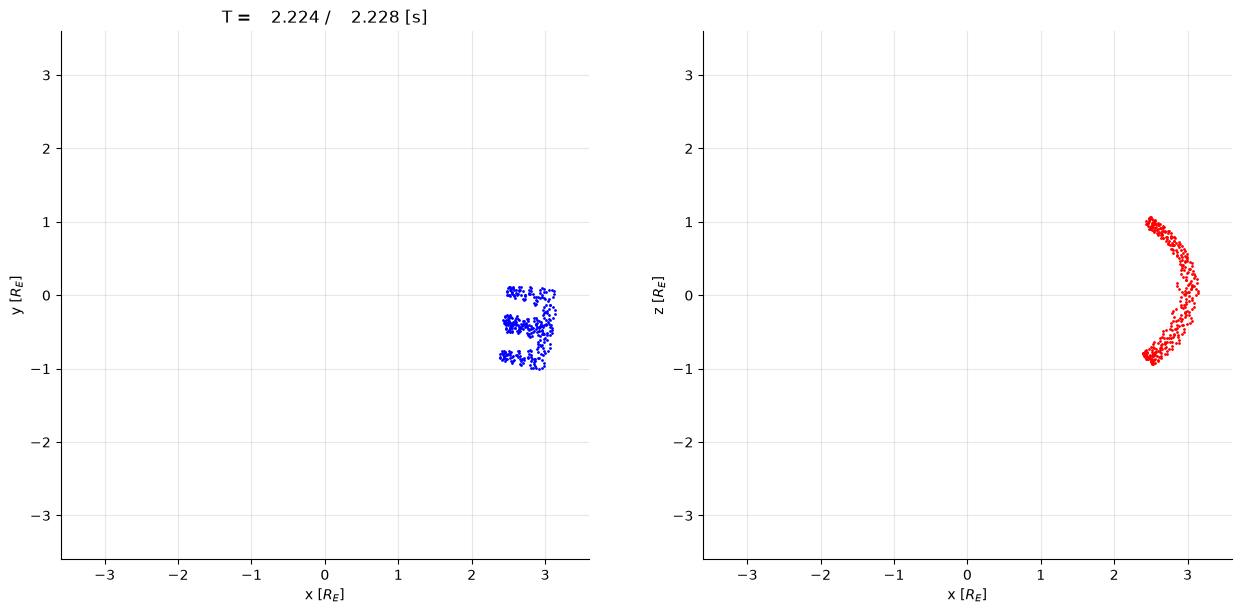

In [16]:
live = LivePlotter(ax_lim=3.6, length_unit=R_EARTH, unit_label=r"$R_E$")
sim = BorisC(trapped.copy(), dip, dt=Tc/40, t_max=2*tau_b, store_dt=Tc/10)
_ = sim.run(live_plotter=live, live_every=40)
live.close()

## 13. Summary

| section | feature | verified against |
|---|---|---|
| 2 | all field models, `plot_field_lines`, both `CustomField` APIs | $B_\text{pole}/B_\text{eq} = 2$, $B\propto r^{-3}$, scalar API = vector API |
| 3 | `gyroradius`, `gyrofrequency`, `suggest_dt`, `check_dt_resolution`, `plot_trajectory_2d` | $r_L$, $\omega_c$, sense of rotation |
| 4 | magnetic mirror in a `CustomField` | $z_m = L\cot\alpha_0$, $T_b = 2\pi L/(v\sin\alpha_0)$, $\mu$ invariant |
| 5 | `UniformEB`, `random_ensemble` | $\mathbf v_E = \mathbf E\times\mathbf B/B^2$ for every particle |
| 6 | `BorisA/B/C`, `RKnonrel`, `RKrel`, `relative_energy_error`, `plot_speed` | Boris-B phase lag $\theta - 2\arctan(\theta/2)$, energy conservation, $r_L\propto\gamma$ |
| 7 | `CyclotronWaveField`, time-dependent `CustomField` | $\dot v_\perp = qE_0/2m$ on resonance |
| 8 | `EarthDipole`, `dipole_initial_conditions`, `plot_trajectory_3d`, adaptive `RKrel` | exact $\tau_b$ integral, Hamlin $\omega_d$, westward drift, $\mu$, $\Delta t\propto 1/B$ |
| 9 | `radiated_power`, `total_radiated_energy`, `spectrum_fft`, `spectrum_retarded` | Liénard power, line at $f_c$, harmonics $n\omega_c$ |
| 10 | `maxwellian_ensemble`, `relativistic_thermal_ensemble`, `ensemble_spectrum` | Maxwell–Jüttner $\langle\gamma\rangle$, thermal $\sigma_v$, line vs continuum |
| 11 | `plot_overview`, `make_overview_gif`, `make_panel_gif` | visual |
| 12 | `LivePlotter` | visual |